# **NLP Project 2026: Web Novel and Light Novel labels predictions**
##### **Authors: *Arno LESAGE (no. 22202985), Minh Quan Hoang (no. 22509118)***

greta.damo@inria.fr

## 1- Research Questions
**Requirements (120 words):** In the world of bookworms, being able to tell the different genres of a Light Novel (LN) or a Web Novel (WN) based on its description is very common. Unfortunately, this apparent simplicity represent a quite difficult task for computers. Using the not so known [*Web/Light Novel Dataset*](https://www.kaggle.com/datasets/premshinde/weblight-novel-dataset), our goal is to predict, from the description of a book, the associated genre(s). We emits the hypothesis (already used for movies classification) that a description unveils a particular semantic depending on the genres they are associated with. As instance, a LN with the `Horror` tag is more likely to have a *gore* description than a `Romance/School Life` LN. Additionally, we also emit the hypothesis of high correlation between genres (`Adventure` implies `Fantasy` or `Drama/Romance`).  

**Required Reflection:** 

**[Q1] Why is your research question non trivial?** Multiple difficulties arise with this research question, but the two main difficulties are the high number of genres (35 in our dataset), but also their correlation together, which would render discrimination attempt difficult (Note: maybe it correlation could be turn into strength).

**[Q2] What linguistic phenomenon does it involve?** The linguistics phenomenon involved we want to capture here is the underlying semantics of the different genres. We expect more joyful "words" and sentences structures for genres like `Romance/Comedy`, more tendentious for `Adult/Ecchi/Harem/Gender Bender`, more youthful for `Shoujo/Shounen/Adventure` and so on.

**[Q3] What would falsify your hypothesis?** A possible justification for our hypothesis being falsified could be that the translation of the description from the original language (Chinese, Korean, Japanese, Vietnamese, ...) to english removed some details and damaged the underlying semantics. 

### **Libraries**

In [2]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from itertools import chain

%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

### **Import the dataset (original-wn)**

In [3]:
df = pd.read_csv("datasets/original-wn-dataset.csv")
df.describe(include="all")

,novel_id,url,title,associated_names,img_url,showtype,genres,tags,description,related_series,...,publishers,en_pubs,release_frequency,weekly_rank,monthly_rank,all_time_rank,monthly_rank_reading_list,all_time_rank_reading_list,total_reading_list_rank,chapters
count,11770.000000,11770,11770,11770,11770,11700,11770,11770,11766,11770,...,11770,11770,11769,11770,11770,11770,11770,11770,11770.000000,11770
unique,NaN,11770,11768,11619,10159,20,6014,11215,11676,1325,...,1213,69,3721,474,2600,8282,3091,6533,NaN,10488
top,NaN,after-the-breakup-i-went-viral-in-the-entertai...,The Imperial Concubine Just Wants To Be a Salt...,[],https://www.novelupdates.com/img/noimagefound.jpg,Web Novel (CN),['Fantasy' 'Romance'],[],N/A\n,"{'related_series': array([], dtype=object), 't...",...,['jjwxc'],[],Every 2000 Day(s),#2000,#2000,#14613,#15649,#11754,NaN,"{'chapters': array([], dtype=object), 'total': 0}"
freq,NaN,1,2,97,1607,5592,230,155,66,10398,...,2216,10454,118,6097,5699,13,418,13,NaN,1283
mean,34047.713084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1664.066950,NaN
std,19129.992708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2436.728268,NaN
min,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,NaN
25%,18403.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,NaN
50%,35094.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.000000,NaN
75%,50761.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981.000000,NaN


For our NLP classification task, we are interested on the following columns `novel_id`, `title`, `genres`, `tags` and `description`.

In [4]:
df_filtered = df.loc[:, ["novel_id", "title", "genres", "tags", "description"]]
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...",['Drama' 'Fantasy' 'Romance' 'Supernatural'],['Amnesia' 'Beautiful Female Lead' 'Clever Pro...,"Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,['Fantasy' 'Romance' 'Shoujo'],['Adventurers' 'Elemental Magic' 'Familiars' '...,A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,['Action' 'Adventure' 'Fantasy' 'Historical' '...,['Beautiful Female Lead' 'Businessmen' 'Childc...,"To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,['Romance' 'School Life' 'Shoujo'],['Female Protagonist' 'Modern Day' 'Short Stor...,"My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,['Psychological' 'Romance' 'Shounen Ai' 'Slice...,['Arranged Marriage' 'Calm Protagonist' 'Cold ...,Lin You He excelled in everything – his looks...


### **Preprocess Dataset Format**

Using the `.head()` command, we observe that the `genres` and `tags` columns are encoded into space separated list, which are not recognised in Python, so we will have to change the format to proper lists.

In [5]:
def colToList (x:str) -> list[str]:
    # Detect the separator
    x = re.sub(r"'[\n ].?'", ",",x)
    
    # Remove the indicator of the raw space separated list and split on coma
    xSplit = x.removeprefix("['").removesuffix("']").split(",")
    
    # Return the list where the text is capitalize (it is just prettier)
    return list(map(str.capitalize, xSplit))

# Apply the split
df_filtered.loc[:,"genres"] = df_filtered.loc[:,"genres"].apply(lambda x: colToList(x))
df_filtered.loc[:,"tags"] = df_filtered.loc[:,"tags"].apply(lambda x: colToList(x))
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...","[Drama, Fantasy, Romance, Supernatural]","[Amnesia, Beautiful female lead, Clever protag...","Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,"[Fantasy, Romance, Shoujo]","[Adventurers, Elemental magic, Familiars, Fema...",A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,"[Action, Adventure, Fantasy, Historical, Roman...","[Beautiful female lead, Businessmen, Childcare...","To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,"[Romance, School life, Shoujo]","[Female protagonist, Modern day, Short story, ...","My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,"[Psychological, Romance, Shounen ai, Slice of ...","[Arranged marriage, Calm protagonist, Cold pro...",Lin You He excelled in everything – his looks...


### **Some stats on the dataset**
Now that everything is correctly imported, we will observe some statistics on our dataset to understand it.
##### **Description language** 

C:\Users\arnol\AppData\Local\Temp\ipykernel_23080\1866244222.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


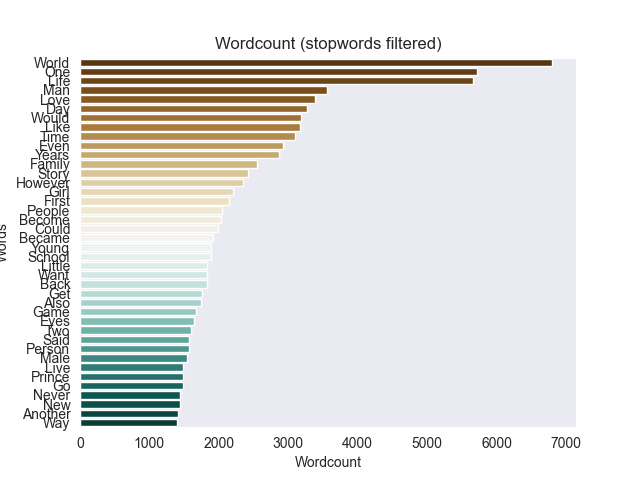

In [6]:
descriptionList = list(map(str,df_filtered.loc[:,"description"].to_list()))
descriptionString = " ".join(descriptionList)
# Match all words and digits
wordDescriptionList = re.findall(r"[\w\d-]+",descriptionString)

# Remove the stopwords
wordDescriptionList = [i.capitalize() for i in wordDescriptionList if i.lower() not in stop_words]

# Apply the counter
wordDescriptionListCounter = Counter(wordDescriptionList)

# Sort the counter
wordDescriptionListCounterSorted = [[],[]]
for word in sorted(wordDescriptionListCounter, key=lambda x:wordDescriptionListCounter[x], reverse=True):
    wordDescriptionListCounterSorted[0].append(word)
    wordDescriptionListCounterSorted[1].append(wordDescriptionListCounter[word])

# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=wordDescriptionListCounterSorted[1][:40],
    y=wordDescriptionListCounterSorted[0][:40],
    palette="BrBG"    
)
plt.title("Wordcount (stopwords filtered)")
plt.xlabel("Wordcount")
plt.ylabel("Words")

plt.show()

##### **Genres stats**
First how genres are distributed:

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Slice of life', 'Harem', 'School life', 'Supernatural', 'Yaoi', 'Mature', 'Adult', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Smut', 'Shounen ai', 'Xuanhuan', 'Historical', 'Seinen', 'Ecchi', 'Horror', 'Xianxia', 'Gender bender', 'Yuri', 'Mecha', 'Shoujo ai', 'Wuxia', 'Sports'], [7523, 6309, 4105, 3743, 3672, 3332, 2210, 2048, 1743, 1731, 1627, 1486, 1277, 1043, 1042, 984, 941, 935, 903, 886, 865, 784, 769, 673, 669, 639, 580, 406, 377, 313, 294, 184, 118, 112, 106]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_23080\3904004382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


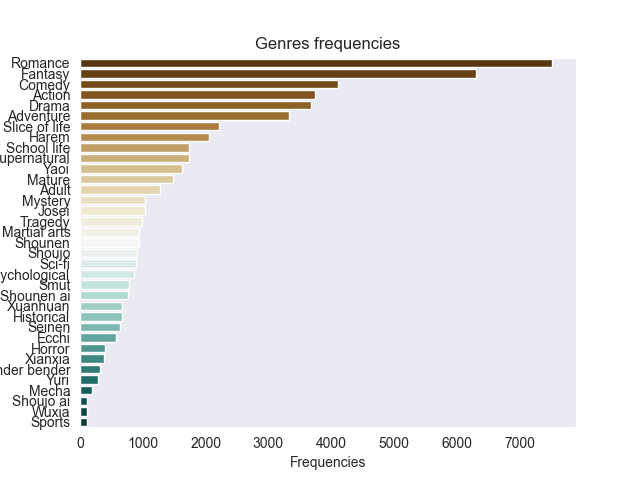

In [7]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_filtered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

Second, how do genres interacts togethers: 

In [8]:
# Create the genre id dictionary
genreToGenreID = {genre:i for i, genre in enumerate(set(genresList))}
genreIDtoGenre = {value:key for key, value in genreToGenreID.items()}
print(genreToGenreID, genreIDtoGenre, sep="\n")

# Create the genreCount dictionary
genreMatrix = np.zeros((len(genreIDtoGenre),len(genreIDtoGenre)), dtype=int)

## For all genres
for genres in df_filtered.loc[:,"genres"].tolist():
    # If it is the only genre, then loop to itself
    if len(genres)==1:
        genreMatrix[genreToGenreID[genres[0]], genreToGenreID[genres[0]]] += 1
        continue
    # Otherwise, add a link to all couple of genre which are differerent
    for genre1 in genres:
        for genre2 in genres:
            if genre1 != genre2:
                genreMatrix[genreToGenreID[genre1], genreToGenreID[genre2]] += 1
print(genreMatrix)

{'Psychological': 0, 'Horror': 1, 'Supernatural': 2, 'Xuanhuan': 3, 'Martial arts': 4, 'Action': 5, 'Romance': 6, 'Yuri': 7, 'Slice of life': 8, 'Shoujo': 9, 'Adult': 10, 'Mature': 11, 'Historical': 12, 'Fantasy': 13, 'Mystery': 14, 'Shounen ai': 15, 'School life': 16, 'Wuxia': 17, 'Josei': 18, 'Ecchi': 19, 'Xianxia': 20, 'Mecha': 21, 'Smut': 22, 'Seinen': 23, 'Sci-fi': 24, 'Yaoi': 25, 'Drama': 26, 'Adventure': 27, 'Tragedy': 28, 'Sports': 29, 'Harem': 30, 'Gender bender': 31, 'Comedy': 32, 'Shoujo ai': 33, 'Shounen': 34}
{0: 'Psychological', 1: 'Horror', 2: 'Supernatural', 3: 'Xuanhuan', 4: 'Martial arts', 5: 'Action', 6: 'Romance', 7: 'Yuri', 8: 'Slice of life', 9: 'Shoujo', 10: 'Adult', 11: 'Mature', 12: 'Historical', 13: 'Fantasy', 14: 'Mystery', 15: 'Shounen ai', 16: 'School life', 17: 'Wuxia', 18: 'Josei', 19: 'Ecchi', 20: 'Xianxia', 21: 'Mecha', 22: 'Smut', 23: 'Seinen', 24: 'Sci-fi', 25: 'Yaoi', 26: 'Drama', 27: 'Adventure', 28: 'Tragedy', 29: 'Sports', 30: 'Harem', 31: 'Gender

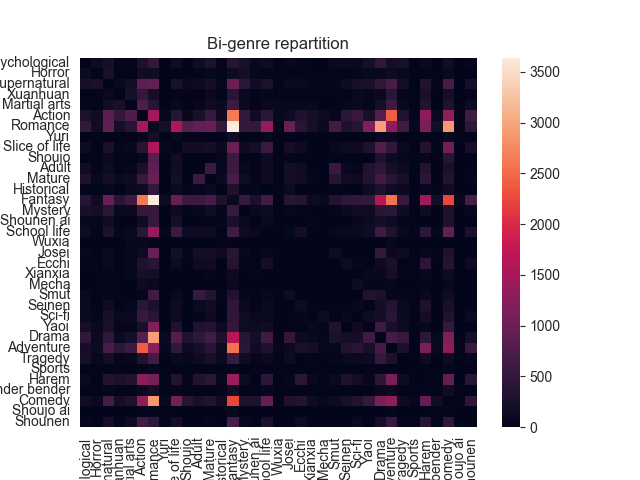

In [10]:
# Make a plot
plt.close("all")
sns.heatmap(genreMatrix,
            xticklabels=list(genreToGenreID.keys()),
            yticklabels=list(genreToGenreID.keys()))
plt.title("Bi-genre repartition")
plt.xlabel("Genre")
plt.ylabel("Genre")

plt.show()

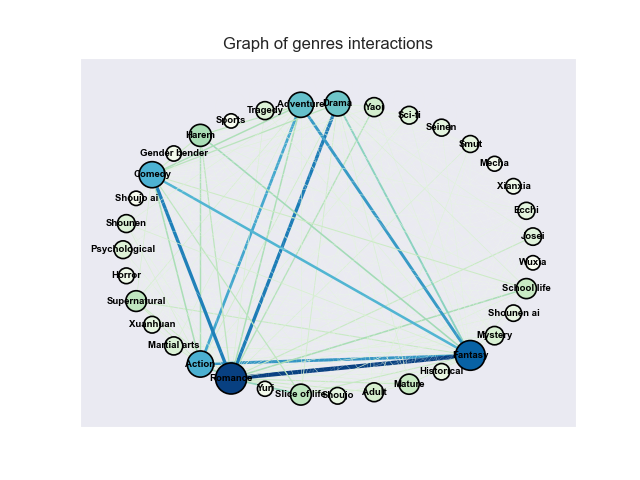

In [11]:
# Make the graph for visibility
G = nx.from_numpy_array(genreMatrix)
G = nx.relabel_nodes(G, dict(enumerate(list(genreToGenreID.keys()))))

# Compute the weights of each edges for the graph
weights = np.array(list(nx.get_edge_attributes(G,"weight").values()))
weights = weights/weights.max()

# Compute the degree of each node to infer nodes sizes
deg = dict(G.degree(weight="weight"))
node_sizes = [100 + 400 * deg[n] / max(deg.values()) for n in G.nodes()]

# Plot the graph
plt.close("all")
nx.draw_networkx(
                 G,                         # The graph 
                 pos=nx.shell_layout(G),    # The layout
                 width=3*weights,           # The width of the edges
                 edge_color=weights,        # Edge colour defined by the weights
                 edge_cmap=plt.cm.GnBu,     # Colour map of the edges
                 font_size="x-small",       # The font size
                 font_color="black",        # The font colour
                 font_weight="bold",        # We want bold
                 font_family="Arial",       # We want Arial
                 node_size=node_sizes,      # The size of the nodes
                 edgecolors="black",        # The border colour of the nodes
                 linewidths=1.2,            # Contour colour of the nodes
                 node_color=node_sizes,     # Colour of the node depends on the degree
                 cmap=plt.cm.GnBu           # Colour map of the nodes
)

# Show the graph
plt.title("Graph of genres interactions")
plt.show()